# Banking Risk Analytics System – Loan Default Prediction & Risk Insights

## Credit Risk Analytics – Executive Summary

This project develops a machine learning based credit risk assessment system using historical loan data. The goal is to predict borrower default probability and support data-driven lending decisions.

Three machine learning models were trained and evaluated: Logistic Regression, Random Forest, and XGBoost. XGBoost achieved the best performance with a ROC-AUC of 0.73 and was selected as the final model.

Borrowers were segmented into risk tiers using predicted probability of default (PD). Portfolio analysis showed that high-risk borrowers account for the majority of expected losses.

Key results from the portfolio simulation include:

• Total expected portfolio loss before strategy: $217.8M
• Rejecting the top 20% highest-risk borrowers reduces expected loss by $44M
• High-risk borrowers contribute nearly 79% of total expected loss

The model enables lenders to prioritize low-risk borrowers, reduce credit losses, and improve portfolio quality through risk-based approval policies.

This project demonstrates how machine learning can support real-world credit decision systems used by financial institutions.


# Step 1: Problem Definition & Business Context

## Business Problem
The objective of this project is to develop a **Banking Risk Analytics System** that helps banks predict loan defaults and make informed lending decisions. The system will assess the risk of potential borrowers and recommend approvals, rejections, or manual review based on risk tiers.

## Key Performance Indicators (KPIs)
- **Default Rate:** Percentage of loans that default within the repayment period.
- **Expected Loss (EL):** Estimated financial loss from defaulting loans, calculated as:
  
  EL = Probability of Default × Exposure × Loss Given Default
- **Risk Tiers:** Classifying borrowers into Low, Medium, and High risk.
- **Approval Rate vs. Risk:** Proportion of loans approved within each risk tier.

## Target Audience
- Bank executives
- Credit risk managers
- Lending decision-makers

## Business Impact
By implementing this system, the bank can:
- Reduce non-performing assets (NPA)
- Prioritize loan approvals to low-risk borrowers
- Identify high-risk clients for further review
- Optimize the lending strategy in alignment with the bank's risk appetite

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


- Loading accepted loans dataset using Pandas `read_csv`.
- Compression='gzip' handles large compressed CSV without unzipping manually.
- `low_memory=False` prevents type inference warnings.
- Initial inspection helps identify columns for cleaning and feature engineering.

In [2]:
import warnings

# Suppress all warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

# Load accepted loans dataset
accepted_path = '/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz'
df = pd.read_csv(accepted_path, compression='gzip', low_memory=False)

# Quick check
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Handling Large Dataset (Sampling)

- Use recent 2–3 years for speed or sample ~50k rows.
- Keeps dataset realistic but manageable.

In [4]:
# Convert issue date to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

# Filter recent 2016–2018 loans
df = df[(df['issue_d'] >= '2016-01-01') & (df['issue_d'] <= '2018-12-31')]


print("dataset shape:", df.shape)

dataset shape: (1373228, 151)


In [5]:
# Shape
print("Rows:", df.shape[0], "Columns:", df.shape[1])

# Info: types and missing values
df.info()

# Summary statistics
df.describe().T

Rows: 1373228 Columns: 151
<class 'pandas.core.frame.DataFrame'>
Index: 1373228 entries, 421097 to 2260698
Columns: 151 entries, id to settlement_term
dtypes: datetime64[ns](1), float64(113), object(37)
memory usage: 1.6+ GB


,count,mean,min,25%,50%,75%,max,std
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,1373228.0,15235.481599,1000.0,8000.0,12800.0,20000.0,40000.0,9642.010772
funded_amnt,1373228.0,15235.461209,1000.0,8000.0,12800.0,20000.0,40000.0,9642.011874
funded_amnt_inv,1373228.0,15230.921501,725.0,8000.0,12800.0,20000.0,40000.0,9640.536025
int_rate,1373228.0,12.994344,5.31,9.44,11.99,15.77,30.99,5.099198
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,7754.0,12705.618415,340.31,6322.2,11069.52,17785.8325,40306.41,7991.994889
hardship_last_payment_amount,7754.0,197.878639,0.01,43.59,131.19,288.3225,1407.86,206.919071
settlement_amount,16245.0,5364.492321,161.0,2342.12,4364.0,7358.0,28503.0,3938.934339
settlement_percentage,16245.0,48.652374,0.65,45.0,45.01,50.0,100.0,6.63565


In [6]:
for cols in df:
    print(cols)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

## Missing Summary

In [7]:
import pandas as pd

# Show all columns without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Missing values summary
missing_count = df.isnull().sum()
missing_percent = (missing_count / df.shape[0]) * 100
missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

# Display all columns with any missing values
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_percent
member_id,1373228,100.0000
desc,1373205,99.9983
orig_projected_additional_accrued_interest,1367142,99.5568
hardship_payoff_balance_amount,1365474,99.4353
hardship_last_payment_amount,1365474,99.4353
payment_plan_start_date,1365474,99.4353
hardship_type,1365474,99.4353
hardship_status,1365474,99.4353
hardship_start_date,1365474,99.4353
deferral_term,1365474,99.4353


# Step 2: Data Cleaning

- **Dropped columns with >90% missing values** to avoid false or misleading data.
- **Removed irrelevant columns** that are not useful for prediction or dashboards (`desc`, `url`, `title`, etc.).
- **Filled numeric missing values with median** to maintain realistic distributions.
- **Filled categorical missing values with "Unknown"**.
- **Resulting dataset:** 1373228 rows × 108 columns.

In [8]:
import pandas as pd
import numpy as np

# Copy original dataframe
df_clean = df.copy()

# Identify columns with missing %
missing_percent = (df_clean.isnull().sum() / df_clean.shape[0]) * 100

# Drop columns >90% missing
cols_drop_90 = missing_percent[missing_percent > 90].index.tolist()

# Keep IDs & geo columns even if sparse
cols_drop_90 = [c for c in cols_drop_90 if c not in ['id','member_id','zip_code','addr_state']]

# Drop columns 80-90% missing (unless needed later) - drop for now
cols_drop_80_90 = missing_percent[(missing_percent > 80) & (missing_percent <= 90)].index.tolist()
cols_drop_80_90 = [c for c in cols_drop_80_90 if c not in ['id','zip_code','addr_state']]

# Combine columns to drop
cols_to_drop = cols_drop_90 + cols_drop_80_90

# Drop clearly irrelevant columns
irrelevant_cols = ['url','desc','title','next_pymnt_d','last_pymnt_d','last_credit_pull_d']
cols_to_drop += [c for c in irrelevant_cols if c in df_clean.columns]

# Drop all selected columns
df_clean.drop(columns=cols_to_drop, inplace=True)

# Fill numeric missing values with median
num_cols = df_clean.select_dtypes(include=['float64','int64']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Fill categorical missing values with 'Unknown'
cat_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('Unknown')

# Summary
print("Cleaned dataset shape:", df_clean.shape)
print("Number of numeric columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))
print("Dropped columns:", cols_to_drop)

Cleaned dataset shape: (1373228, 108)
Number of numeric columns: 88
Number of categorical columns: 19
Dropped columns: ['desc', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_t

In [9]:
df_clean.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag'], dtype='object', length=108)

In [10]:
df_clean.drop('member_id', axis=1, inplace=True)

In [11]:
df_clean.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       ...
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag'], dtype='object', length=107)

# Step 3: Feature Engineering

- Converted `term` to numeric `term_months`.
- Converted `emp_length` to numeric `emp_length_num`.
- Calculated `credit_history_years` from `earliest_cr_line`.
- Created `prior_default_flag` to capture previous default history.
- Label encoded categorical features (`grade`, `sub_grade`, `home_ownership`, `verification_status`, `purpose`, `addr_state`).
- Dropped original object columns after conversion.
- **Dataset now fully numeric and ready for modeling.**

In [12]:
df_analytics = df_clean.copy()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Make a copy to work on
df_feat = df_clean.copy()

# Convert term to numeric (months)
df_feat['term_months'] = df_feat['term'].str.replace(' months','').astype(int)

# Convert emp_length to numeric
def emp_length_to_num(x):
    if pd.isnull(x) or x == 'Unknown':
        return np.nan
    elif '< 1' in x:
        return 0.5
    elif '10+' in x:
        return 10
    else:
        try:
            return int(x.split()[0])
        except:
            return np.nan

df_feat['emp_length_num'] = df_feat['emp_length'].apply(emp_length_to_num)
# Fill missing with median
df_feat['emp_length_num'] = df_feat['emp_length_num'].fillna(df_feat['emp_length_num'].median())

# Convert earliest_cr_line to credit history in years
df_feat['earliest_cr_line'] = pd.to_datetime(df_feat['earliest_cr_line'], errors='coerce')
df_feat['credit_history_years'] = (df_feat['issue_d'] - df_feat['earliest_cr_line']).dt.days / 365
df_feat['credit_history_years'] = df_feat['credit_history_years'].fillna(df_feat['credit_history_years'].median())

# Create target: prior default flag
df_feat['prior_default_flag'] = df_feat['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off','Default'] else 0
)

# Encode categorical features using Label Encoding
cat_cols = ['grade','sub_grade','home_ownership','verification_status','purpose','addr_state']
for col in cat_cols:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col])

# Drop redundant/original object columns
drop_cols = ['term','emp_length','earliest_cr_line']
df_feat.drop(columns=drop_cols, inplace=True)

# Preview the processed dataset
print("Feature engineered dataset shape:", df_feat.shape)
df_feat.head()

Feature engineered dataset shape: (1373228, 108)


,id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,zip_code,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,term_months,emp_length_num,credit_history_years,prior_default_flag
421097,130954621,5000.0000,5000.0000,5000.0000,20.3900,186.8200,3,18,General Manager,4,50000.0000,2,2018-03-01,Current,n,9,740xx,35,21.8000,1.0000,665.0000,669.0000,0.0000,9.0000,5.0000,0.0000,116.0000,23.2000,18.0000,w,3780.3100,3780.3100,2043.6900,2043.6900,1219.6900,824.0000,0.0000,0.0000,0.0000,186.8200,609.0000,605.0000,0.0000,9.0000,1.0000,Individual,0.0000,0.0000,19344.0000,0.0000,2.0000,0.0000,1.0000,16.0000,14118.0000,51.0000,1.0000,2.0000,85.0000,58.0000,500.0000,9.0000,0.0000,5.0000,3.0000,3869.0000,384.0000,23.2000,1.0000,0.0000,80.0000,13.0000,11.0000,11.0000,0.0000,11.0000,36.0000,2.0000,33.0000,4.0000,2.0000,2.0000,2.0000,2.0000,15.0000,2.0000,2.0000,2.0000,5.0000,0.0000,0.0000,1.0000,1.0000,77.8000,0.0000,0.0000,0.0000,33430.0000,19344.0000,500.0000,27820.0000,N,Cash,N,36,8.0000,9.1671,0
421098,130964697,15000.0000,15000.0000,15000.0000,9.9200,483.4500,1,6,IT Director,3,196000.0000,1,2018-03-01,Current,n,2,337xx,9,18.2900,0.0000,700.0000,704.0000,0.0000,65.0000,19.0000,0.0000,24243.0000,46.3000,53.0000,w,10878.5000,10878.5000,5301.4200,5301.4200,4121.5000,1179.9200,0.0000,0.0000,0.0000,483.4500,694.0000,690.0000,0.0000,45.0000,1.0000,Individual,0.0000,0.0000,534954.0000,4.0000,3.0000,2.0000,2.0000,6.0000,113470.0000,59.0000,4.0000,12.0000,10495.0000,51.0000,52400.0000,4.0000,1.0000,7.0000,15.0000,31468.0000,7368.0000,74.1000,0.0000,0.0000,141.0000,236.0000,4.0000,4.0000,5.0000,11.0000,36.0000,6.0000,33.0000,0.0000,4.0000,10.0000,5.0000,16.0000,11.0000,14.0000,37.0000,10.0000,19.0000,0.0000,0.0000,0.0000,6.0000,98.0000,75.0000,0.0000,0.0000,605228.0000,137713.0000,28500.0000,147178.0000,N,Cash,N,36,2.0000,19.6795,0
421099,130955326,11200.0000,11200.0000,11200.0000,30.7900,367.8200,6,30,Client services,4,44000.0000,0,2018-03-01,Current,n,7,030xx,29,43.9700,1.0000,665.0000,669.0000,2.0000,6.0000,8.0000,0.0000,1526.0000,24.6000,14.0000,w,10193.7300,10193.7300,4007.7000,4007.7000,1006.2700,3001.4300,0.0000,0.0000,0.0000,367.8200,629.0000,625.0000,0.0000,70.0000,1.0000,Joint App,0.0000,0.0000,67173.0000,1.0000,4.0000,1.0000,4.0000,8.0000,65647.0000,89.0000,1.0000,1.0000,1011.0000,84.0000,6200.0000,8.0000,1.0000,10.0000,5.0000,8397.0000,632.0000,66.7000,0.0000,0.0000,124.0000,128.0000,5.0000,5.0000,0.0000,34.0000,35.0000,0.0000,35.0000,1.0000,2.0000,3.0000,2.0000,3.0000,8.0000,4.0000,6.0000,3.0000,8.0000,0.0000,0.0000,0.0000,2.0000,71.4000,0.0000,0.0000,0

## EDA

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12,6)

## Distribution of loan amount

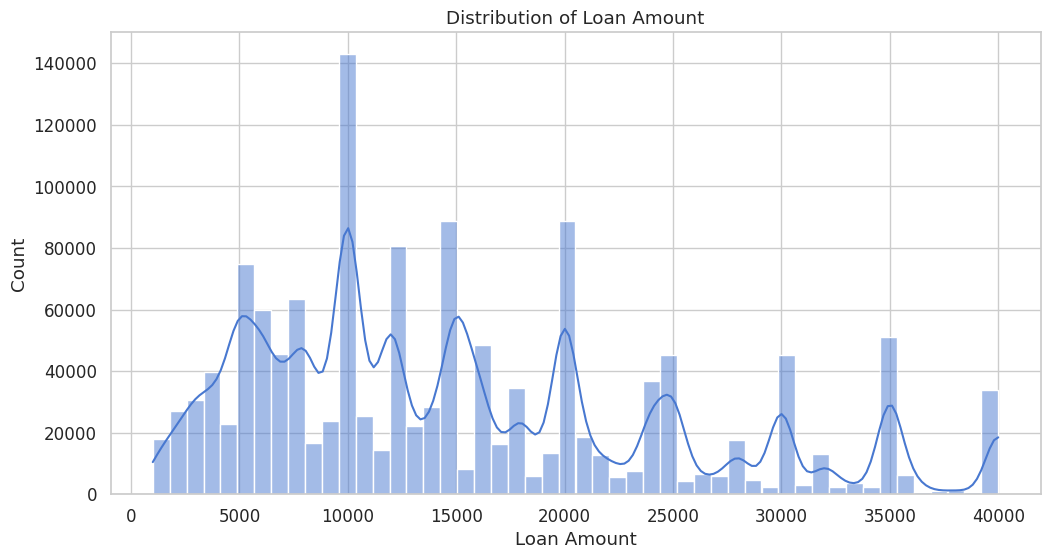

In [15]:
plt.figure()
sns.histplot(df_feat['loan_amnt'], bins=50, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Count')
plt.show()


In [16]:
print("Loan Amount Summary:")
print(df_feat['loan_amnt'].describe())
print("Skewness:", df_feat['loan_amnt'].skew())

Loan Amount Summary:
count   1373228.0000
mean      15235.4816
std        9642.0108
min        1000.0000
25%        8000.0000
50%       12800.0000
75%       20000.0000
max       40000.0000
Name: loan_amnt, dtype: float64
Skewness: 0.8000082046013447


Distribution is reasonable, but slightly skewed — may affect models sensitive to scale.

## Interest rate distribution

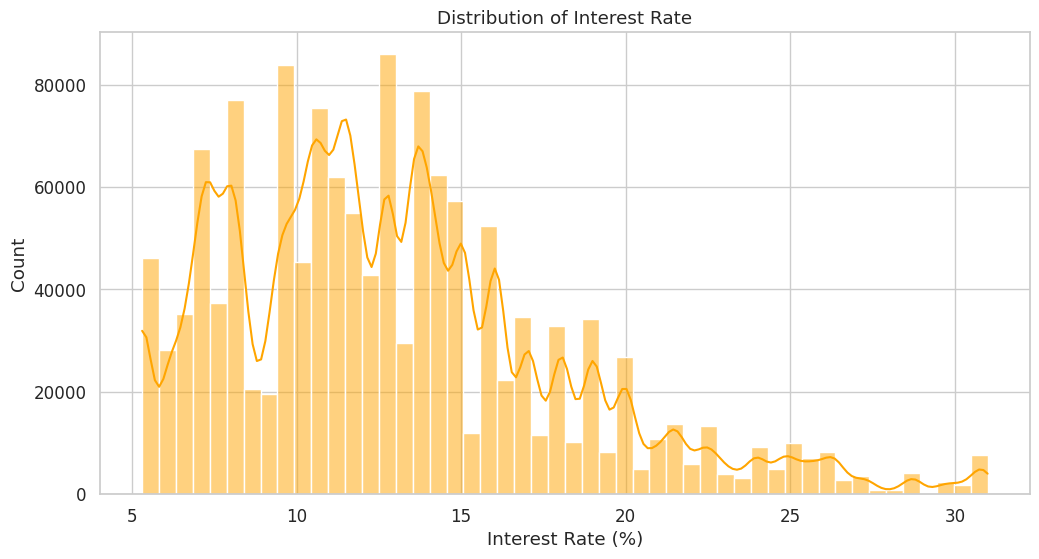

In [17]:
plt.figure()
sns.histplot(df_feat['int_rate'], bins=50, kde=True, color='orange')
plt.title('Distribution of Interest Rate')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Count')
plt.show()


In [18]:
print("Interest Rate Summary:")
print(df_feat['int_rate'].describe())
print("Skewness:", df_feat['int_rate'].skew())

Interest Rate Summary:
count   1373228.0000
mean         12.9943
std           5.0992
min           5.3100
25%           9.4400
50%          11.9900
75%          15.7700
max          30.9900
Name: int_rate, dtype: float64
Skewness: 0.9149986695097239


Skewness shows some extreme high-interest loans — could consider capping or log-transform for modeling.

## Credit history in years distribution

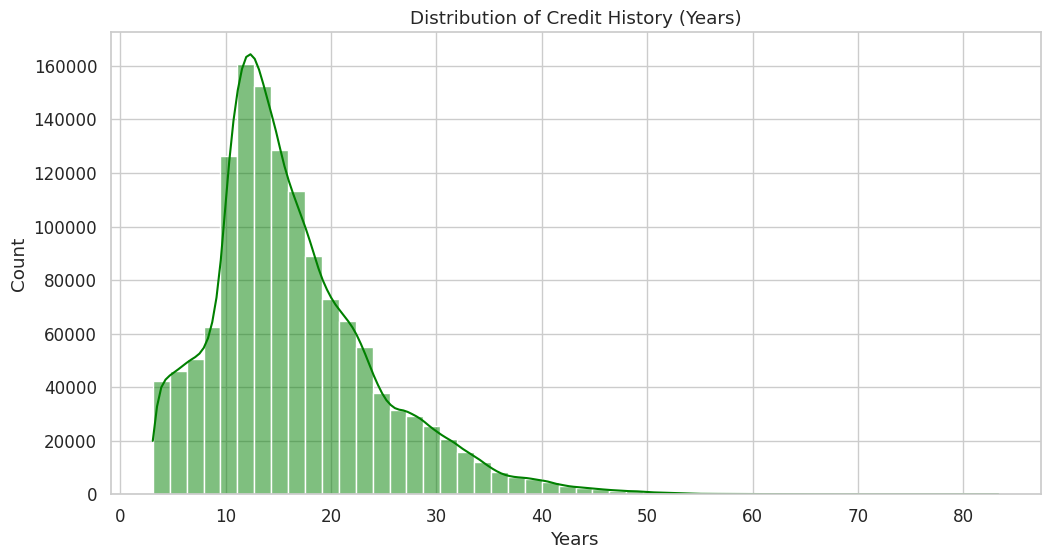

In [19]:
plt.figure()
sns.histplot(df_feat['credit_history_years'], bins=50, kde=True, color='green')
plt.title('Distribution of Credit History (Years)')
plt.xlabel('Years')
plt.ylabel('Count')
plt.show()

In [20]:
print("Credit History (Years) Summary:")
print(df_feat['credit_history_years'].describe())
print("Skewness:", df_feat['credit_history_years'].skew())

Credit History (Years) Summary:
count   1373228.0000
mean         16.4388
std           7.8212
min           3.0795
25%          11.2603
50%          14.8438
75%          20.4247
max          83.3096
Name: credit_history_years, dtype: float64
Skewness: 1.077755535071974


Mostly moderate-length credit histories; outliers are long-term credit accounts.

## Target variable distribution

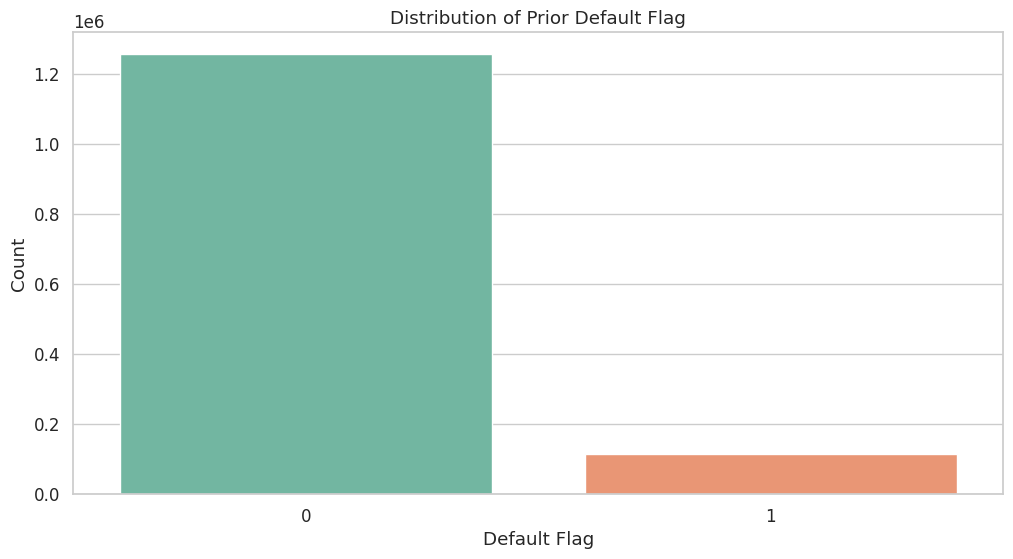

In [21]:
plt.figure()
sns.countplot(x='prior_default_flag', data=df_feat, palette='Set2')
plt.title('Distribution of Prior Default Flag')
plt.xlabel('Default Flag')
plt.ylabel('Count')
plt.show()

In [22]:
print("Prior Default Flag Distribution:")
print(df_feat['prior_default_flag'].value_counts())

Prior Default Flag Distribution:
prior_default_flag
0    1256933
1     116295
Name: count, dtype: int64


Target is imbalanced (~9% default history), must consider in modeling.

## Loan amount vs. Default Flag (boxplot)

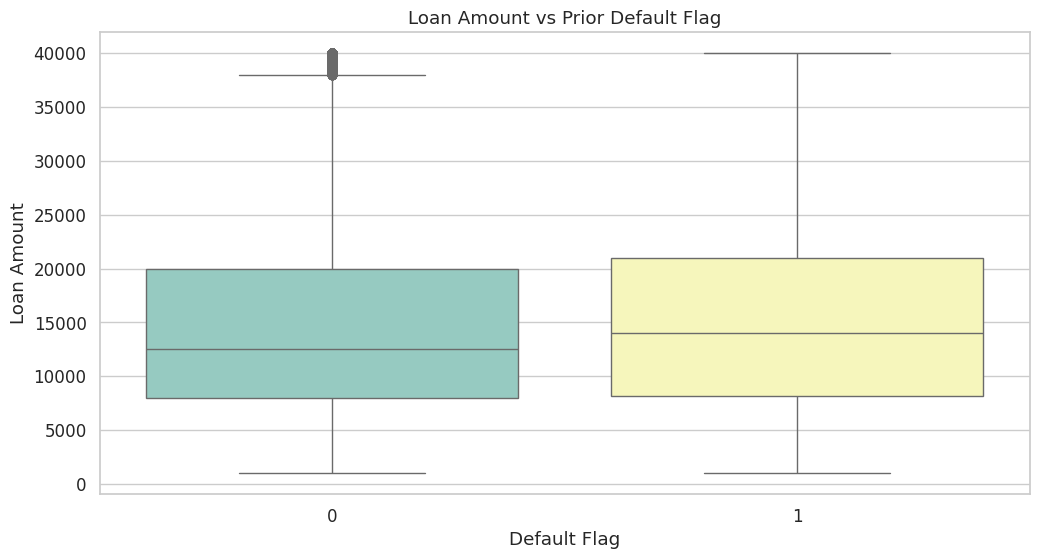

In [23]:
plt.figure()
sns.boxplot(x='prior_default_flag', y='loan_amnt', data=df_feat, palette='Set3')
plt.title('Loan Amount vs Prior Default Flag')
plt.xlabel('Default Flag')
plt.ylabel('Loan Amount')
plt.show()

## Correlation heatmap (numeric features only)

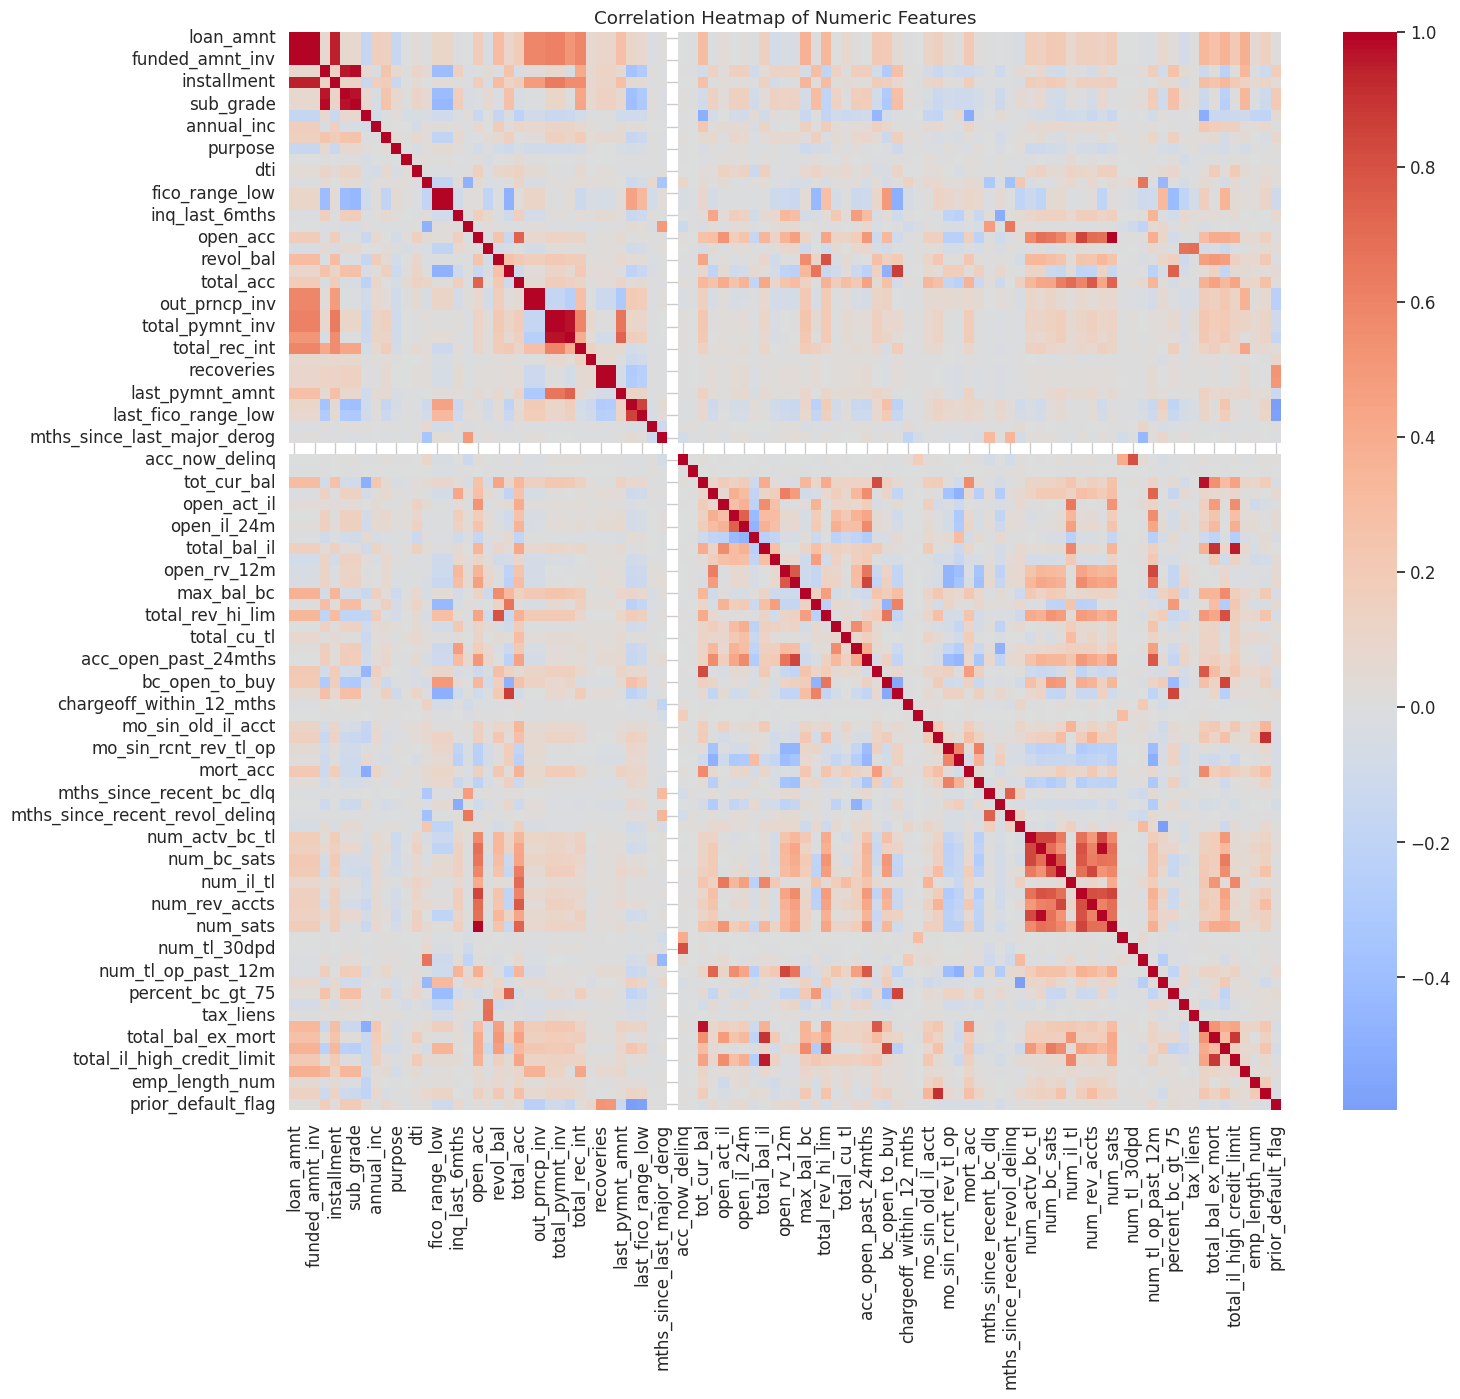

In [24]:
plt.figure(figsize=(16,14))
numeric_cols = df_feat.select_dtypes(include=np.number).columns
corr_matrix = df_feat[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Distribution of grades vs Default

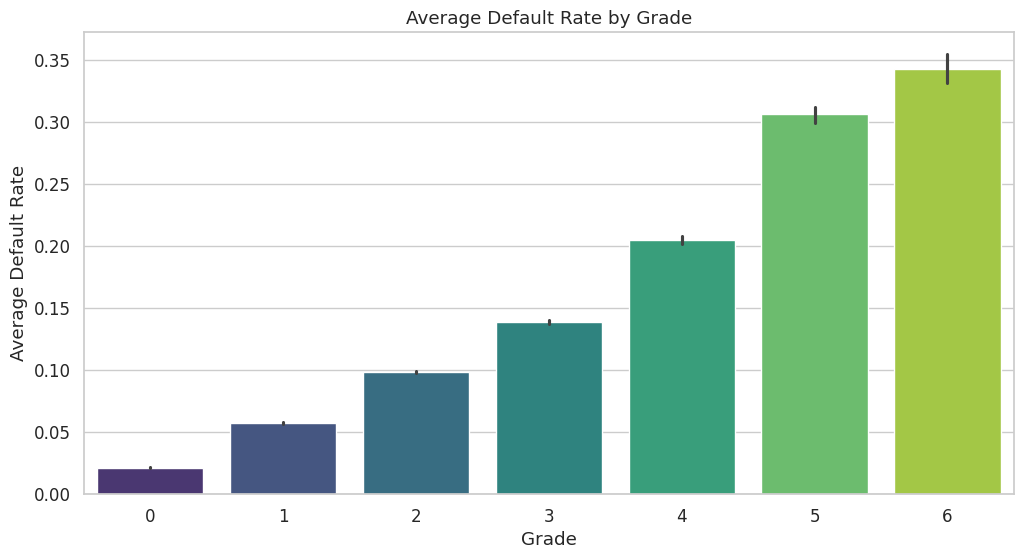

In [25]:
plt.figure()
sns.barplot(x='grade', y='prior_default_flag', data=df_feat, palette='viridis')
plt.title('Average Default Rate by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Default Rate')
plt.show()

In [26]:
grade_default_rate = df_feat.groupby('grade')['prior_default_flag'].mean()
print("Average Default Rate by Grade:")
print(grade_default_rate)

Average Default Rate by Grade:
grade
0   0.0212
1   0.0575
2   0.0984
3   0.1386
4   0.2048
5   0.3058
6   0.3423
Name: prior_default_flag, dtype: float64


Loan grade strongly correlates with defaults. Low-grade loans (5–6) have high defaults; high-grade loans (0–1) rarely default. This validates the grading system and can be a predictive feature.

## Revolving utilization vs Default

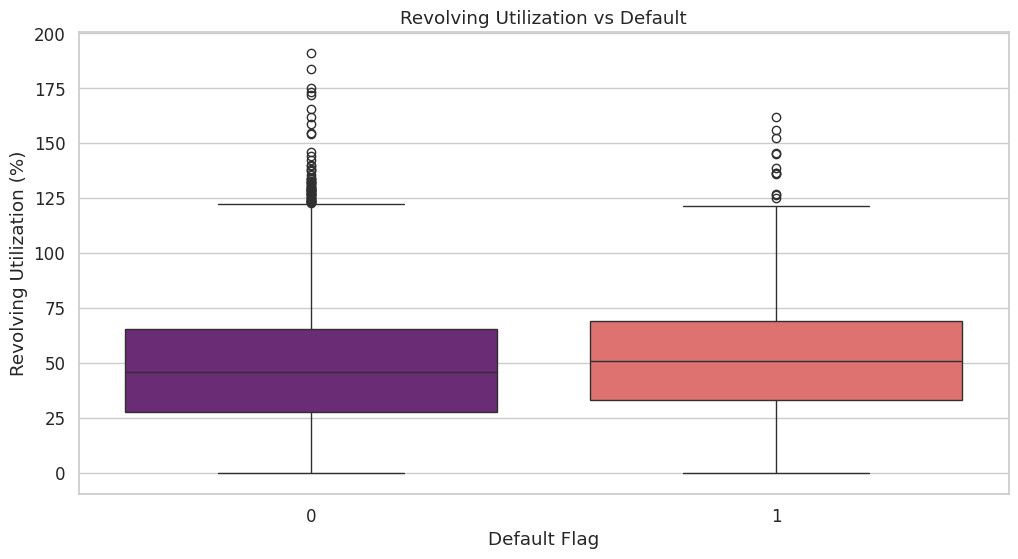

In [27]:
plt.figure()
sns.boxplot(x='prior_default_flag', y='revol_util', data=df_feat, palette='magma')
plt.title('Revolving Utilization vs Default')
plt.xlabel('Default Flag')
plt.ylabel('Revolving Utilization (%)')
plt.show()

In [28]:
print("Revolving Utilization Summary:")
print(df_feat['revol_util'].describe())
print("Skewness:", df_feat['revol_util'].skew())

Revolving Utilization Summary:
count   1373228.0000
mean         47.2786
std          24.7774
min           0.0000
25%          28.1000
50%          46.3000
75%          66.0000
max         191.0000
Name: revol_util, dtype: float64
Skewness: 0.11718677470742304


Mostly balanced utilization, but outliers exist — may need capping at 100% for realism.

In [29]:
import pandas as pd
import numpy as np
from scipy.stats import skew

# Select numeric columns
num_cols = df_feat.select_dtypes(include=np.number).columns

# Create summary dataframe
summary_list = []
for col in num_cols:
    data = df_feat[col].dropna()
    summary_list.append({
        'feature': col,
        'count': data.count(),
        'mean': data.mean(),
        'median': data.median(),
        'std': data.std(),
        'min': data.min(),
        '1%': data.quantile(0.01),
        '25%': data.quantile(0.25),
        '50%': data.quantile(0.5),
        '75%': data.quantile(0.75),
        '99%': data.quantile(0.99),
        'max': data.max(),
        'skewness': skew(data)
    })

numeric_summary = pd.DataFrame(summary_list)
numeric_summary = numeric_summary.sort_values(by='skewness', ascending=False).reset_index(drop=True)

# Display the summary
numeric_summary

,feature,count,mean,median,std,min,1%,25%,50%,75%,99%,max,skewness
0,tot_coll_amt,1373228,236.9224,0.0000,7244.2647,0.0000,0.0000,0.0000,0.0000,0.0000,4707.0000,6214661.0000,740.5131
1,annual_inc,1373228,79909.2772,66000.0000,134883.9235,0.0000,15000.0000,47000.0000,66000.0000,95000.0000,285000.0000,110000000.0000,471.0016
2,delinq_amnt,1373228,13.2412,0.0000,764.4211,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,249925.0000,105.4560
3,num_tl_120dpd_2m,1373228,0.0005,0.0000,0.0251,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,7.0000,62.8544
4,tax_liens,1373228,0.0457,0.0000,0.3702,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,61.0000,28.3758
5,dti,1373228,19.2687,17.9600,16.8723,-1.0000,1.5900,11.8900,17.9600,24.8700,49.9700,999.0000,28.2646
6,num_tl_30dpd,1373228,0.0024,0.0000,0.0510,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,23.4654
7,total_rec_late_fee,1373228,1.5043,0.0000,12.3388,-0.0000,0.0000,0.0000,0.0000,0.0000,43.9073,1484.3400,22.6748
8,acc_now_delinq,1373228,0.0036,0.0000,0.0639,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,7.0000,20.8690
9,chargeoff_within_12_mths,1373228,0.0082,0.0000,0.1031,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,9.0000,18.8663


## Detect suspicious leakage columns

In [30]:
# columns that happen after loan is issued
leakage_keywords = [
    'pymnt','payment','recover','collection','out_prncp',
    'last_pymnt','total_rec','settlement'
]

leakage_cols = [c for c in df_feat.columns if any(k in c.lower() for k in leakage_keywords)]

print("Potential leakage columns:")
print(leakage_cols)

Potential leakage columns:
['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'collections_12_mths_ex_med', 'debt_settlement_flag']


## Drop leakage columns

In [31]:
df_model = df_feat.drop(columns=leakage_cols)
print("Dataset after removing leakage:", df_model.shape)

Dataset after removing leakage: (1373228, 95)


## Detect Extreme Skew

Highly skewed features hurt models.

In [32]:
numeric_cols = df_model.select_dtypes(include=['int64','float64']).columns

skew_values = df_model[numeric_cols].skew().sort_values(ascending=False)

print("Top skewed features:")
print(skew_values.head(20))

Top skewed features:
tot_coll_amt               740.5139
annual_inc                 471.0021
delinq_amnt                105.4561
num_tl_120dpd_2m            62.8544
tax_liens                   28.3759
dti                         28.2647
num_tl_30dpd                23.4654
acc_now_delinq              20.8690
chargeoff_within_12_mths    18.8663
num_tl_90g_dpd_24m          16.0288
max_bal_bc                  13.8281
revol_bal                   11.6556
pub_rec                     10.0230
delinq_2yrs                  6.2170
total_rev_hi_lim             5.9481
num_accts_ever_120_pd        5.6713
mo_sin_rcnt_tl               4.8890
total_bal_ex_mort            4.0192
total_bal_il                 3.8249
avg_cur_bal                  3.7563
dtype: float64


## Log Transform Extreme Skew

In [33]:
skewed_features = skew_values[skew_values > 2].index

for col in skewed_features:
    df_model[col] = np.log1p(df_model[col])

log1p() avoids log(0) errors.

In [34]:
(df_model[skewed_features] < 0).sum()

tot_coll_amt                  0
annual_inc                    0
delinq_amnt                   0
num_tl_120dpd_2m              0
tax_liens                     0
dti                           2
num_tl_30dpd                  0
acc_now_delinq                0
chargeoff_within_12_mths      0
num_tl_90g_dpd_24m            0
max_bal_bc                    0
revol_bal                     0
pub_rec                       0
delinq_2yrs                   0
total_rev_hi_lim              0
num_accts_ever_120_pd         0
mo_sin_rcnt_tl                0
total_bal_ex_mort             0
total_bal_il                  0
avg_cur_bal                   0
mo_sin_rcnt_rev_tl_op         0
mths_since_recent_bc          0
tot_hi_cred_lim               0
bc_open_to_buy                0
total_cu_tl                   0
mths_since_rcnt_il            0
pub_rec_bankruptcies          0
total_il_high_credit_limit    0
tot_cur_bal                   0
prior_default_flag            0
open_act_il                   0
total_bc

## Detect Outliers

Outliers distort models.

Use IQR method.

In [35]:
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)

for col in ['loan_amnt','annual_inc','revol_bal']:
    print(col, detect_outliers(df_model, col))

loan_amnt 35215
annual_inc 31808
revol_bal 54541


### Cap Extreme Outliers

Instead of removing rows (bad for big datasets), cap values.

In [36]:
def cap_outliers(df, col):
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)

for col in ['loan_amnt','annual_inc','revol_bal']:
    cap_outliers(df_model, col)

### Detect Sparse Features
- Sparse features = mostly zeros.
- These often appear in delinquency columns.

In [37]:
sparse_cols = []

for col in numeric_cols:
    zero_ratio = (df_model[col] == 0).mean()
    
    if zero_ratio > 0.95:
        sparse_cols.append(col)

print("Sparse features (>95% zeros):")
print(sparse_cols)

Sparse features (>95% zeros):
['acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'tax_liens']


### Convert Sparse Features to Binary

Instead of numeric counts:

In [38]:
for col in sparse_cols:
    df_model[col] = df_model[col].apply(lambda x: 1 if x > 0 else 0)

### Detect Redundant Features

Some columns represent the same concept.

In [39]:
df_model['fico_score'] = (df_model['fico_range_low'] + df_model['fico_range_high']) / 2

df_model.drop(columns=['fico_range_low','fico_range_high'], inplace=True)

In [40]:
df_model['last_fico_range_score'] = (df_model['last_fico_range_low'] + df_model['last_fico_range_high']) / 2

df_model.drop(columns=['last_fico_range_low','last_fico_range_high'], inplace=True)

### Check Suspicious Values

In [41]:
print(df_model[df_model['revol_util'] > 100]['revol_util'].describe())

count   3837.0000
mean     103.0502
std        6.1461
min      100.1000
25%      100.6000
50%      101.2000
75%      102.7000
max      191.0000
Name: revol_util, dtype: float64


In [42]:
df_model['revol_util'] = np.clip(df_model['revol_util'],0,100)

In [43]:
print(df_model[df_model['revol_util'] > 100]['revol_util'].describe())

count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: revol_util, dtype: float64


### Detect Highly Concentrated Categories
If one category dominates, it becomes useless.

In [44]:
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    print(col)
    print(df_model[col].value_counts(normalize=True).head())

id
id
88215728    0.0000
130954621   0.0000
130964697   0.0000
130955326   0.0000
130504052   0.0000
Name: proportion, dtype: float64
emp_title
emp_title
Unknown   0.0841
Teacher   0.0185
Manager   0.0168
Owner     0.0121
Driver    0.0081
Name: proportion, dtype: float64
loan_status
loan_status
Current              0.5994
Fully Paid           0.2931
Charged Off          0.0847
Late (31-120 days)   0.0144
In Grace Period      0.0056
Name: proportion, dtype: float64
zip_code
zip_code
112xx   0.0107
750xx   0.0104
945xx   0.0102
606xx   0.0091
300xx   0.0090
Name: proportion, dtype: float64
initial_list_status
initial_list_status
w   0.8046
f   0.1954
Name: proportion, dtype: float64
application_type
application_type
Individual   0.9125
Joint App    0.0875
Name: proportion, dtype: float64
hardship_flag
hardship_flag
N   0.9994
Y   0.0006
Name: proportion, dtype: float64
disbursement_method
disbursement_method
Cash        0.9431
DirectPay   0.0569
Name: proportion, dtype: float64


In [45]:
df_model.drop(columns=['id','emp_title','hardship_flag'],inplace=True)

In [46]:
df_model.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq

In [47]:
df_model = df_model[df_model['loan_status'].isin(['Fully Paid','Charged Off'])]

df_model['target'] = df_model['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})

df_model.drop(columns=['loan_status'], inplace=True)

In [48]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['zip_code','initial_list_status','application_type','disbursement_method']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

In [49]:
df_model.isnull().sum().sort_values(ascending=False).head(20)

loan_amnt                 0
funded_amnt               0
funded_amnt_inv           0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
home_ownership            0
annual_inc                0
verification_status       0
issue_d                   0
purpose                   0
zip_code                  0
addr_state                0
dti                       0
delinq_2yrs               0
inq_last_6mths            0
mths_since_last_delinq    0
open_acc                  0
pub_rec                   0
dtype: int64

In [50]:
print("Final dataset shape:", df_model.shape)

print("\nMissing values:")
print(df_model.isnull().sum().sum())

print("\nTarget distribution:")
print(df_model['target'].value_counts(normalize=True))

print("\nNumber of features:", df_model.shape[1])

Final dataset shape: (518706, 90)

Missing values:
0

Target distribution:
target
0   0.7759
1   0.2241
Name: proportion, dtype: float64

Number of features: 90


In [51]:
corr_matrix = df_model.corr(numeric_only=True)

In [52]:
import numpy as np

corr_matrix = df_model.corr(numeric_only=True)

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Highly correlated features:", high_corr)

Highly correlated features: ['funded_amnt', 'funded_amnt_inv', 'installment', 'grade', 'sub_grade', 'num_rev_tl_bal_gt_0', 'num_sats', 'total_il_high_credit_limit', 'target']


In [53]:
high_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

print(high_pairs[high_pairs > 0.95])

loan_amnt                       loan_amnt                        1.0000
mort_acc                        mort_acc                         1.0000
mths_since_last_major_derog     mths_since_last_major_derog      1.0000
mths_since_recent_bc            mths_since_recent_bc             1.0000
last_fico_range_score           last_fico_range_score            1.0000
num_tl_30dpd                    num_tl_30dpd                     1.0000
open_rv_12m                     open_rv_12m                      1.0000
credit_history_years            credit_history_years             1.0000
il_util                         il_util                          1.0000
mths_since_recent_inq           mths_since_recent_inq            1.0000
grade                           grade                            1.0000
num_sats                        num_sats                         1.0000
acc_now_delinq                  acc_now_delinq                   1.0000
application_type                application_type                

In [54]:
cols_to_drop = [
    'funded_amnt',
    'funded_amnt_inv',
    'installment',
    'grade',
    'sub_grade',
    'num_rev_tl_bal_gt_0',
    'num_sats',
    'total_il_high_credit_limit',
    'prior_default_flag',
    'last_fico_range_score'
]

df_model.drop(columns=cols_to_drop, inplace=True)

In [55]:
import numpy as np

corr_matrix = df_model.corr(numeric_only=True)

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

[]


In [56]:
df_model.columns

Index(['loan_amnt', 'int_rate', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_a

In [57]:
# Reduce rare categories to "Other"

cat_cols = ['home_ownership','verification_status','purpose','addr_state','zip_code','disbursement_method','initial_list_status','application_type']

for col in cat_cols:
    
    freq = df_model[col].value_counts(normalize=True)
    
    rare = freq[freq < 0.01].index
    
    df_model[col] = df_model[col].replace(rare, 'Other')

print("Rare categories merged")

Rare categories merged


In [58]:
df_model = pd.get_dummies(
    df_model,
    columns=['home_ownership','verification_status','purpose','addr_state','zip_code','disbursement_method','initial_list_status','application_type'],
    drop_first=True
)

print("Encoding complete")
print("New dataset shape:", df_model.shape)

Encoding complete
New dataset shape: (518706, 118)


In [59]:
df_model['issue_d'] = pd.to_datetime(df_model['issue_d'])

In [60]:
train = df_model[df_model['issue_d'] < '2017-01-01']
test  = df_model[df_model['issue_d'] >= '2017-01-01']

X_train = train.drop(['target','issue_d'], axis=1)
y_train = train['target']

X_test = test.drop(['target','issue_d'], axis=1)
y_test = test['target']

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (293095, 116)
Test shape: (225611, 116)


In [61]:
print("Missing values in train:", X_train.isnull().sum().sum())
print("Missing values in test:", X_test.isnull().sum().sum())

Missing values in train: 0
Missing values in test: 0


In [62]:
df_model.dtypes.value_counts()

float64           63
bool              46
int64              8
datetime64[ns]     1
Name: count, dtype: int64

In [63]:
df_model['target'].value_counts(normalize=True)

target
0   0.7759
1   0.2241
Name: proportion, dtype: float64

In [64]:
import numpy as np

corr_matrix = train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated columns:")
print(high_corr)

Highly correlated columns:
['avg_cur_bal', 'tot_hi_cred_lim', 'credit_history_years']


In [65]:
train_df = train.drop(columns=high_corr)
test_df = test.drop(columns=high_corr)

In [66]:
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [67]:
X_train.shape
X_test.shape
y_train.value_counts()
y_test.value_counts()

loan_status
Current               164619
Fully Paid             80490
Charged Off            23251
Late (31-120 days)      3954
In Grace Period         1525
Late (16-30 days)        799
Default                    8
Name: count, dtype: int64

In [68]:
df_model = df_model.drop(columns=["issue_d"])

In [69]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(414964, 116)
(103742, 116)
target
0   0.7759
1   0.2241
Name: proportion, dtype: float64
target
0   0.7759
1   0.2241
Name: proportion, dtype: float64


**Find which columns contain infinity**

In [72]:
import numpy as np

inf_cols = X_train.columns[np.isinf(X_train).any()]

print("Columns with infinity values:")
print(inf_cols)

Columns with infinity values:
Index(['dti'], dtype='object')


In [73]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [74]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [76]:
print("Any infinity:", np.isinf(X_train).sum().sum())
print("Any NaN:", X_train.isna().sum().sum())

Any infinity: 0
Any NaN: 0


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict_proba(X_test)[:,1]

auc_lr = roc_auc_score(y_test, y_pred_lr)

print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.7094466079590737


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, y_pred_rf)

print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7173780858241892


In [80]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict_proba(X_test)[:,1]

auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print("XGBoost AUC:", auc_xgb)

XGBoost AUC: 0.7330822192160921


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7792     0.5375  0.1076    0.1794
1        Random Forest    0.7789     0.6684  0.0271    0.0522
2              XGBoost    0.7848     0.5906  0.1304    0.2136


In [82]:
from sklearn.metrics import roc_curve
import numpy as np

# predicted probabilities from your best model (example: XGBoost)
y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

ks_statistic = np.max(tpr - fpr)

print("KS Statistic:", round(ks_statistic,4))

KS Statistic: 0.3384


In [83]:
leak_cols = [
"last_fico_range_score",
"recoveries",
"collection_recovery_fee",
"total_rec_prncp",
"total_rec_int",
"total_pymnt"
]

for col in leak_cols:
    if col in X_train.columns:
        print("Leakage column present:", col)

In [84]:
import pandas as pd

importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(20))

int_rate                0.1404
term_months             0.0509
home_ownership_4        0.0340
verification_status_2   0.0252
fico_score              0.0247
mort_acc                0.0242
addr_state_36           0.0177
addr_state_46           0.0151
tot_hi_cred_lim         0.0147
open_rv_24m             0.0145
addr_state_5            0.0142
purpose_11              0.0137
loan_amnt               0.0135
dti                     0.0132
num_actv_rev_tl         0.0129
avg_cur_bal             0.0116
verification_status_1   0.0113
bc_open_to_buy          0.0111
inq_last_6mths          0.0102
addr_state_39           0.0102
dtype: float32


In [85]:
train_pred = xgb.predict_proba(X_train)[:,1]

from sklearn.metrics import roc_auc_score

print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC:", roc_auc_score(y_test, y_pred_xgb))

Train AUC: 0.7641501234012097
Test AUC: 0.7330822192160921


In [86]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_pred_xgb)

print("PR AUC:", pr_auc)

PR AUC: 0.43913893630379014


**Create Project Folder Structure**

In [88]:
import os

base_path = "/kaggle/working/credit_risk_project"

folders = [
    "scripts",
    "models",
    "data",
    "outputs"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created.")

Project folders created.


**Save Train/Test Datasets**

In [89]:
X_train.to_csv(f"{base_path}/data/X_train.csv", index=False)
X_test.to_csv(f"{base_path}/data/X_test.csv", index=False)
y_train.to_csv(f"{base_path}/data/y_train.csv", index=False)
y_test.to_csv(f"{base_path}/data/y_test.csv", index=False)

print("Datasets saved.")

Datasets saved.


**Save the Trained Model**

In [90]:
import joblib

joblib.dump(xgb, f"{base_path}/models/xgboost_credit_model.pkl")

print("Model saved.")

Model saved.


**Save Feature List**

In [91]:
import json

feature_list = list(X_train.columns)

with open(f"{base_path}/models/model_features.json", "w") as f:
    json.dump(feature_list, f)

print("Feature list saved.")

Feature list saved.


**Save Evaluation Metrics**

In [92]:
from sklearn.metrics import roc_auc_score

train_pred = xgb.predict_proba(X_train)[:,1]
test_pred = xgb.predict_proba(X_test)[:,1]

train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.7641501234012097
Test AUC: 0.7330822192160921


In [93]:
import json

metrics = {
    "train_auc": float(train_auc),
    "test_auc": float(test_auc),
    "ks_statistic": float(ks_statistic)
}

with open(f"{base_path}/outputs/model_metrics.json", "w") as f:
    json.dump(metrics, f)

print("Metrics saved.")

Metrics saved.


In [94]:
import json

with open(f"{base_path}/outputs/model_metrics.json") as f:
    print(json.load(f))

{'train_auc': 0.7641501234012097, 'test_auc': 0.7330822192160921, 'ks_statistic': 0.338421233893888}


**Save Feature Importance**

In [95]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.to_csv(
    f"{base_path}/outputs/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


**Generate Script Files**

In [96]:
script_files = {
    "data_pipeline.py": "# Data loading and preprocessing\n",
    "feature_engineering.py": "# Feature engineering functions\n",
    "model_training.py": "# Model training pipeline\n",
    "model_evaluation.py": "# Model evaluation metrics\n",
    "utils.py": "# Helper utilities\n"
}

for filename, content in script_files.items():
    with open(f"{base_path}/scripts/{filename}", "w") as f:
        f.write(content)

print("Script files created.")

Script files created.


**Zip Everything**

In [97]:
import shutil

shutil.make_archive(
    "/kaggle/working/credit_risk_project",
    'zip',
    base_path
)

print("Project zipped.")

Project zipped.


**Import SHAP**

In [98]:
import shap
import numpy as np
import pandas as pd

**Initialize SHAP Explainer for XGBoost**

In [99]:
explainer = shap.TreeExplainer(xgb)

**Calculate SHAP Values**

In [100]:
X_sample = X_test.sample(10000, random_state=42)

shap_values = explainer.shap_values(X_sample)

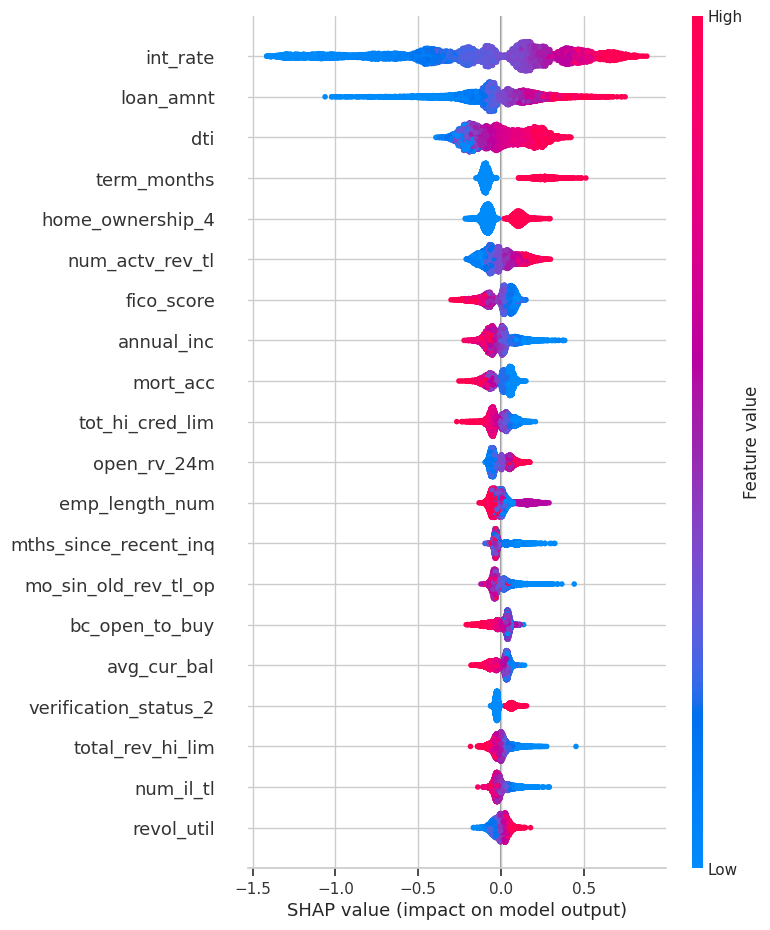

In [101]:
shap.summary_plot(shap_values, X_sample)

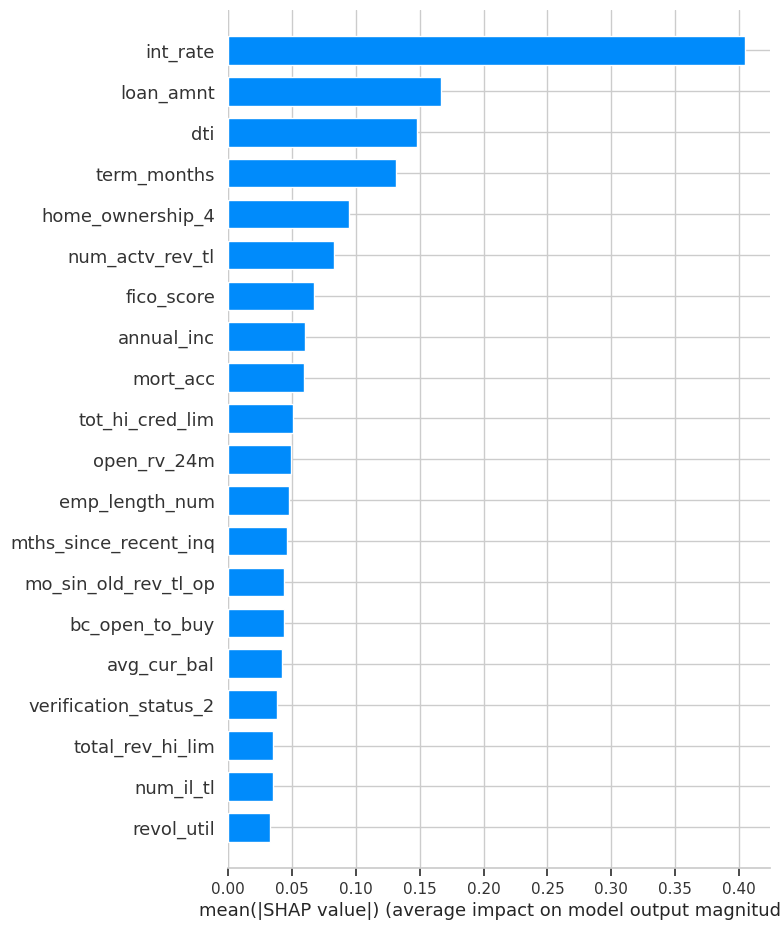

In [102]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [103]:
shap.initjs()

In [105]:
borrower = X_sample.iloc[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    borrower
)

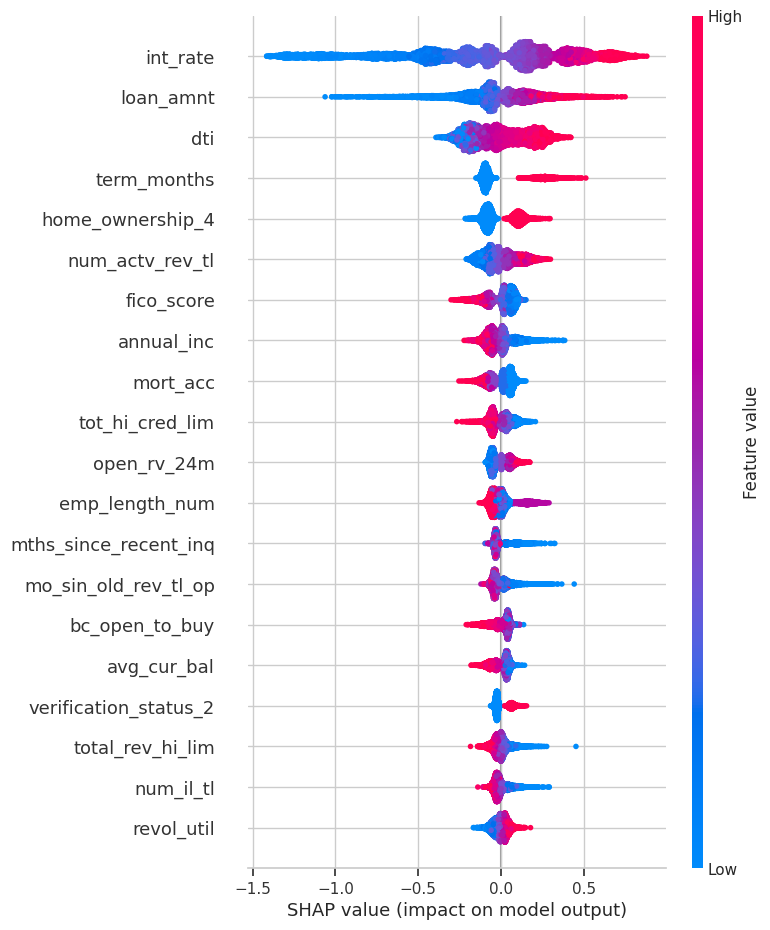

In [106]:
shap.summary_plot(shap_values, X_sample)

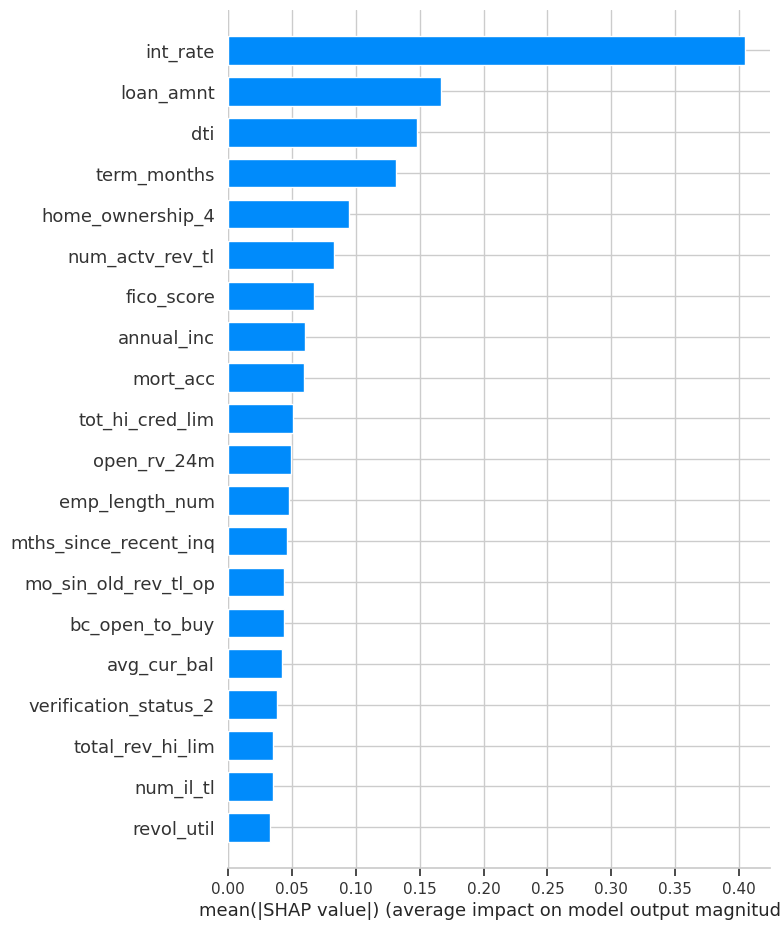

In [107]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

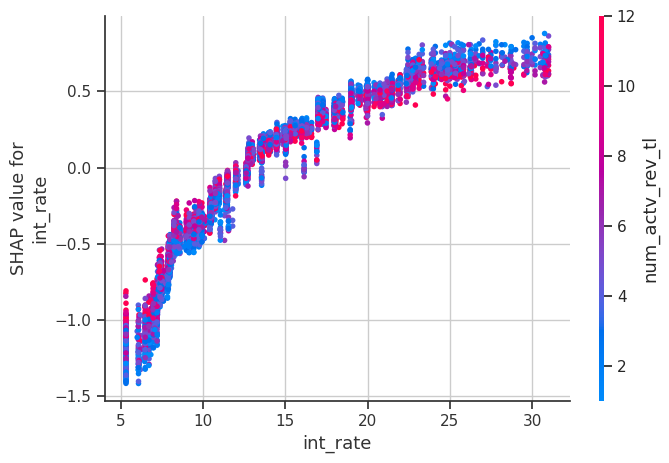

In [108]:
shap.dependence_plot("int_rate", shap_values, X_sample)

In [109]:
y_pred_prob = xgb.predict_proba(X_test)[:,1]

In [110]:
import pandas as pd

risk_df = pd.DataFrame({
    "actual": y_test,
    "probability": y_pred_prob
})

risk_df["risk_band"] = pd.cut(
    risk_df["probability"],
    bins=[0, 0.05, 0.10, 0.20, 1],
    labels=["Low", "Medium", "High", "Very High"]
)

In [111]:
risk_summary = risk_df.groupby("risk_band").agg(
    borrowers=("actual", "count"),
    defaults=("actual", "sum")
)

risk_summary["default_rate"] = risk_summary["defaults"] / risk_summary["borrowers"]

risk_summary

,borrowers,defaults,default_rate
risk_band,,,
Low,7731,207,0.0268
Medium,14652,1043,0.0712
High,30288,4518,0.1492
Very High,51071,17484,0.3423


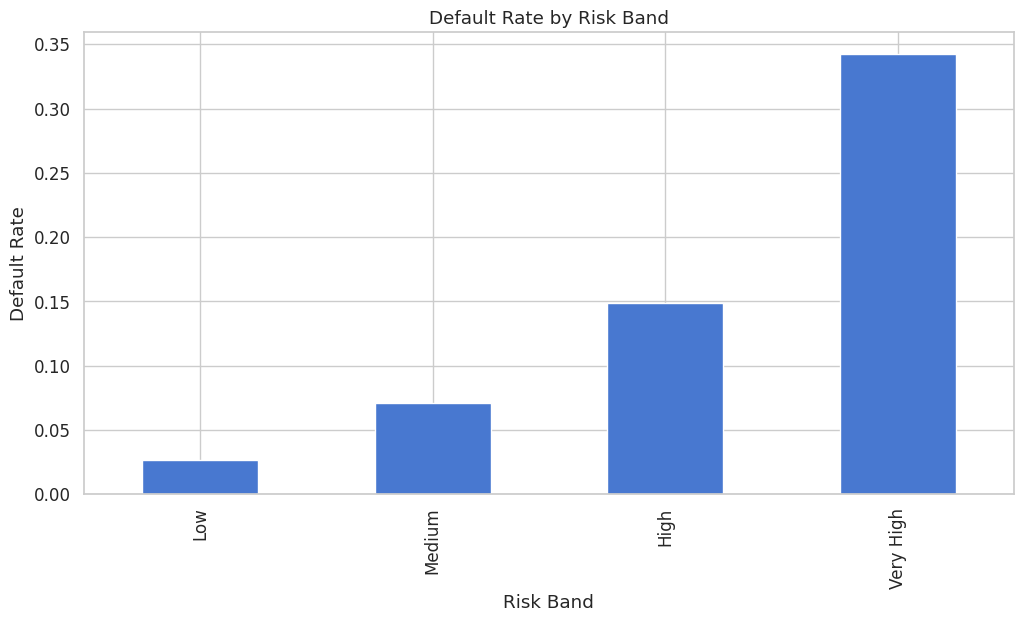

In [112]:
import matplotlib.pyplot as plt

risk_summary["default_rate"].plot(kind="bar")
plt.title("Default Rate by Risk Band")
plt.ylabel("Default Rate")
plt.xlabel("Risk Band")
plt.show()

In [113]:
risk_summary.to_csv(f"{base_path}/outputs/risk_band_summary.csv")

In [114]:
score_df = pd.DataFrame({
    "actual": y_test,
    "probability": y_pred_prob
})

score_df["credit_score"] = 850 - (score_df["probability"] * 550)
score_df["credit_score"] = score_df["credit_score"].astype(int)

score_df.head()

,actual,probability,credit_score
665261,0,0.1233,782
1600227,0,0.3916,634
922009,0,0.2310,722
664888,1,0.1716,755
2203727,1,0.2687,702


In [115]:
score_df["score_band"] = pd.cut(
    score_df["credit_score"],
    bins=[300, 600, 650, 700, 750, 850],
    labels=["Very Risky", "Risky", "Moderate", "Safe", "Very Safe"]
)

In [116]:
score_summary = score_df.groupby("score_band").agg(
    borrowers=("actual", "count"),
    defaults=("actual", "sum")
)

score_summary["default_rate"] = score_summary["defaults"] / score_summary["borrowers"]

score_summary

,borrowers,defaults,default_rate
score_band,,,
Very Risky,8265,4493,0.5436
Risky,9487,3916,0.4128
Moderate,15928,4943,0.3103
Safe,22901,5166,0.2256
Very Safe,47161,4734,0.1004


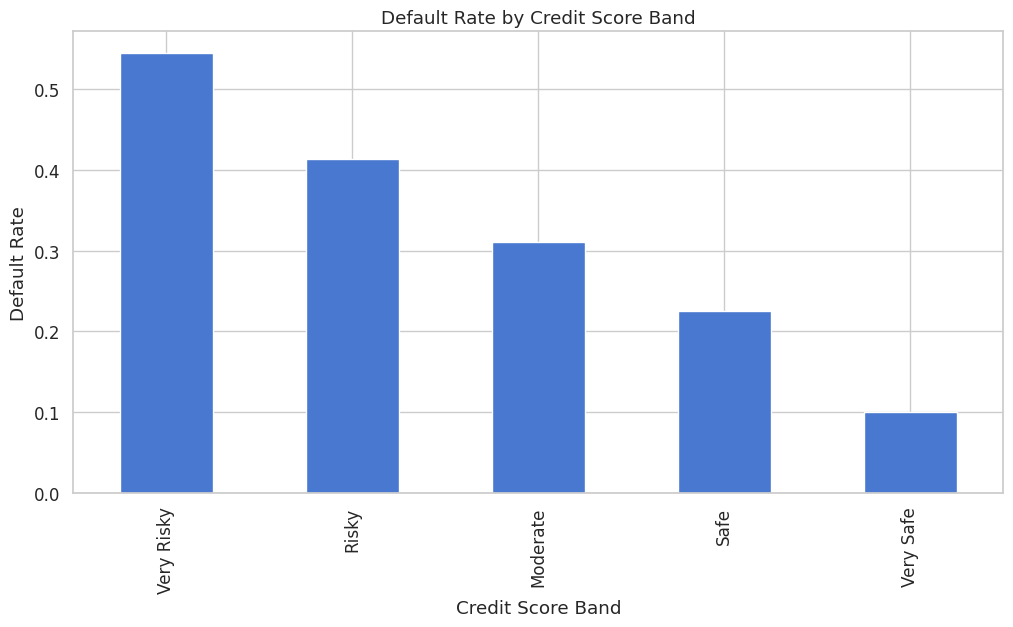

In [117]:
import matplotlib.pyplot as plt

score_summary["default_rate"].plot(kind="bar")
plt.title("Default Rate by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Default Rate")
plt.show()

In [118]:
score_summary.to_csv(f"{base_path}/outputs/credit_score_summary.csv")
score_df.to_csv(f"{base_path}/outputs/credit_scores_test_set.csv", index=False)

In [119]:
import numpy as np

score_df = pd.DataFrame({
    "actual": y_test,
    "probability": y_pred_prob
})

# convert probability to log odds
log_odds = np.log((1 - score_df["probability"]) / score_df["probability"])

# scale to credit score range
score_df["credit_score"] = 650 + (50 * log_odds)

# clip to range
score_df["credit_score"] = score_df["credit_score"].clip(300, 850).astype(int)

score_df.head()

,actual,probability,credit_score
665261,0,0.1233,748
1600227,0,0.3916,672
922009,0,0.2310,710
664888,1,0.1716,728
2203727,1,0.2687,700


In [120]:
score_df["score_band"] = pd.cut(
    score_df["credit_score"],
    bins=[300, 600, 650, 700, 750, 850],
    labels=["Very Risky", "Risky", "Moderate", "Safe", "Very Safe"]
)

In [121]:
score_summary = score_df.groupby("score_band").agg(
    borrowers=("actual", "count"),
    defaults=("actual", "sum")
)

score_summary["default_rate"] = score_summary["defaults"] / score_summary["borrowers"]

score_summary

,borrowers,defaults,default_rate
score_band,,,
Very Risky,148,119,0.8041
Risky,5275,3063,0.5807
Moderate,29536,10517,0.3561
Safe,41022,7725,0.1883
Very Safe,27761,1828,0.0658


In [122]:
score_summary.to_csv(f"{base_path}/outputs/credit_score_summary.csv")
score_df.to_csv(f"{base_path}/outputs/credit_scores_test_set.csv", index=False)

In [123]:
impact_df = score_df.copy()

impact_df = impact_df.sort_values(
    "probability",
    ascending=False
)

In [124]:
reject_fraction = 0.20

cutoff = int(len(impact_df) * reject_fraction)

rejected = impact_df.iloc[:cutoff]
approved = impact_df.iloc[cutoff:]

In [125]:
original_default_rate = impact_df["actual"].mean()

new_default_rate = approved["actual"].mean()

print("Original Default Rate:", round(original_default_rate,4))
print("New Default Rate after rejecting top 20%:", round(new_default_rate,4))

Original Default Rate: 0.2241
New Default Rate after rejecting top 20%: 0.1661


In [126]:
defaults_rejected = rejected["actual"].sum()

print("Defaults prevented:", defaults_rejected)
print("Rejected borrowers:", len(rejected))

Defaults prevented: 9468
Rejected borrowers: 20748


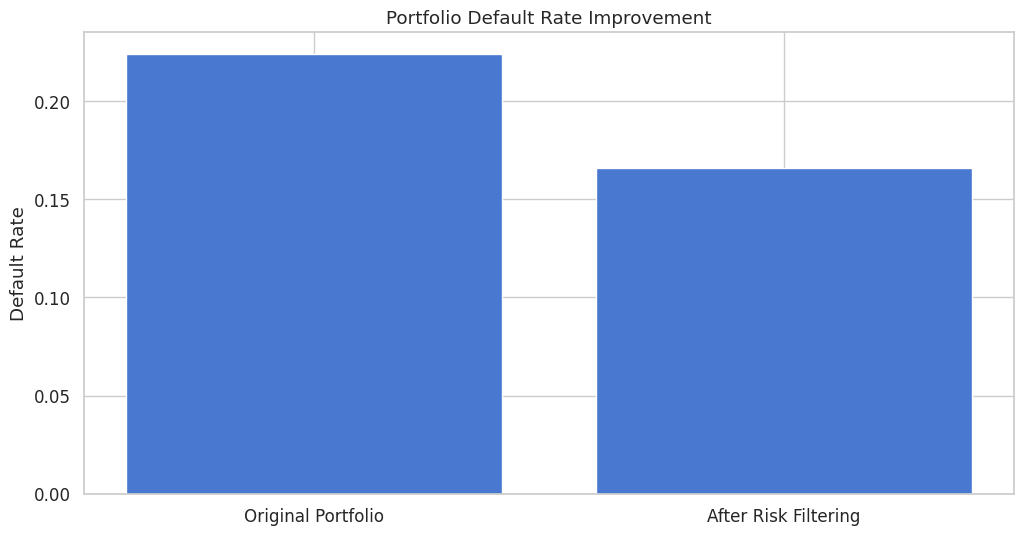

In [127]:
import matplotlib.pyplot as plt

rates = [original_default_rate, new_default_rate]

labels = ["Original Portfolio", "After Risk Filtering"]

plt.bar(labels, rates)
plt.title("Portfolio Default Rate Improvement")
plt.ylabel("Default Rate")
plt.show()

In [128]:
# Expected Loss Modeling

impact_df = score_df.copy()

# Probability of default
impact_df["PD"] = xgb.predict_proba(X_test)[:,1]

# Exposure (loan amount from test data)
impact_df["Exposure"] = X_test["loan_amnt"].values

# Loss Given Default
LGD = 0.6
impact_df["LGD"] = LGD

# Expected Loss
impact_df["Expected_Loss"] = impact_df["PD"] * impact_df["LGD"] * impact_df["Exposure"]

# Portfolio expected loss
total_expected_loss = impact_df["Expected_Loss"].sum()

print("Total Portfolio Expected Loss:", round(total_expected_loss,2))

Total Portfolio Expected Loss: 217794539.25


In [129]:
# Compare Expected Loss Before vs After Rejection

cutoff = int(len(impact_df) * 0.20)

rejected = impact_df.iloc[:cutoff]
approved = impact_df.iloc[cutoff:]

loss_before = impact_df["Expected_Loss"].sum()
loss_after = approved["Expected_Loss"].sum()

print("Expected Loss Before Strategy:", round(loss_before,2))
print("Expected Loss After Rejecting Top 20%:", round(loss_after,2))
print("Loss Reduction:", round(loss_before - loss_after,2))

Expected Loss Before Strategy: 217794539.25
Expected Loss After Rejecting Top 20%: 173790939.26
Loss Reduction: 44003599.99


In [130]:
# Strategy Optimization - Test different rejection levels

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

results = []

for t in thresholds:
    cutoff = int(len(impact_df) * t)
    
    rejected = impact_df.iloc[:cutoff]
    approved = impact_df.iloc[cutoff:]
    
    loss_after = approved["Expected_Loss"].sum()
    
    results.append({
        "Rejection_Rate": t,
        "Expected_Loss_After": loss_after,
        "Loss_Reduction": impact_df["Expected_Loss"].sum() - loss_after
    })

import pandas as pd
strategy_df = pd.DataFrame(results)

print(strategy_df)

   Rejection_Rate  Expected_Loss_After  Loss_Reduction
0          0.0500       206554553.8931   11239985.3618
1          0.1000       195619614.8219   22174924.4329
2          0.1500       184853189.1149   32941350.1399
3          0.2000       173790939.2649   44003599.9900
4          0.2500       162986848.1111   54807691.1438
5          0.3000       152302097.7928   65492441.4621


In [131]:
# Create Risk Bands based on probability of default

impact_df["risk_band"] = pd.cut(
    impact_df["PD"],
    bins=[0, 0.1, 0.2, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_counts = impact_df["risk_band"].value_counts().sort_index()

print(risk_counts)

risk_band
Low Risk       22383
Medium Risk    30288
High Risk      51071
Name: count, dtype: int64


**Default Rate by Risk Tier**

In [132]:
# Attach actual default values
impact_df["actual_default"] = y_test.values

# Default rate by risk band
default_rate_by_risk = impact_df.groupby("risk_band")["actual_default"].mean()

print(default_rate_by_risk)

risk_band
Low Risk      0.0558
Medium Risk   0.1492
High Risk     0.3423
Name: actual_default, dtype: float64


**Approval Policy Simulation**

In [133]:
# Approval policy simulation

approved = impact_df[impact_df["risk_band"] == "Low Risk"]
review = impact_df[impact_df["risk_band"] == "Medium Risk"]
rejected = impact_df[impact_df["risk_band"] == "High Risk"]

print("Approved borrowers:", len(approved))
print("Review borrowers:", len(review))
print("Rejected borrowers:", len(rejected))

print("\nDefault rate (Approved):", round(approved["actual_default"].mean(),4))
print("Default rate (Review):", round(review["actual_default"].mean(),4))
print("Default rate (Rejected):", round(rejected["actual_default"].mean(),4))

Approved borrowers: 22383
Review borrowers: 30288
Rejected borrowers: 51071

Default rate (Approved): 0.0558
Default rate (Review): 0.1492
Default rate (Rejected): 0.3423


**Portfolio Approval Rate**

In [134]:
# Portfolio approval statistics

total_borrowers = len(impact_df)

approval_rate = len(approved) / total_borrowers
review_rate = len(review) / total_borrowers
rejection_rate = len(rejected) / total_borrowers

print("Approval Rate:", round(approval_rate,4))
print("Review Rate:", round(review_rate,4))
print("Rejection Rate:", round(rejection_rate,4))

Approval Rate: 0.2158
Review Rate: 0.292
Rejection Rate: 0.4923


**Expected Loss by Risk Tier**

In [135]:
# Expected loss by risk tier

loss_by_risk = impact_df.groupby("risk_band")["Expected_Loss"].sum()

print(loss_by_risk)

risk_band
Low Risk       10578968.4665
Medium Risk    35863701.2756
High Risk     171351869.5128
Name: Expected_Loss, dtype: float64


**Final Portfolio Summary Table**

In [136]:
# Final portfolio risk summary

portfolio_summary = impact_df.groupby("risk_band").agg(
    Borrowers=("risk_band","count"),
    Default_Rate=("actual_default","mean"),
    Expected_Loss=("Expected_Loss","sum")
)

print(portfolio_summary)

             Borrowers  Default_Rate  Expected_Loss
risk_band                                          
Low Risk         22383        0.0558  10578968.4665
Medium Risk      30288        0.1492  35863701.2756
High Risk        51071        0.3423 171351869.5128


In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    })

model_comparison = pd.DataFrame(results)

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC_AUC
0  Logistic Regression    0.7792     0.5375  0.1076    0.1794   0.7094
1        Random Forest    0.7789     0.6684  0.0271    0.0522   0.7174
2              XGBoost    0.7848     0.5906  0.1304    0.2136   0.7331


In [138]:
from sklearn.metrics import roc_curve
import numpy as np

y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

ks = np.max(tpr - fpr)

print("KS Statistic:", round(ks,4))

KS Statistic: 0.3384


**ROC Curve Visualization**

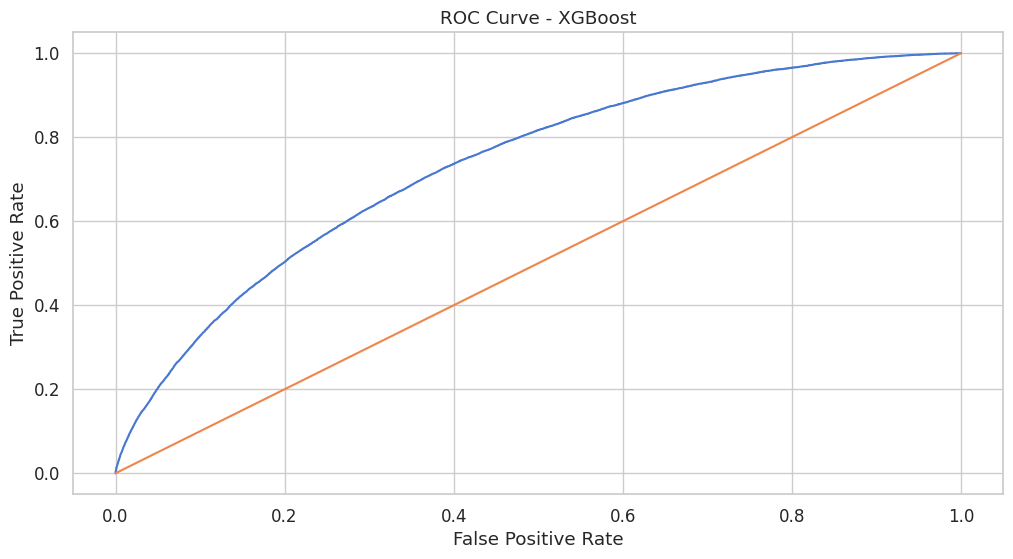

In [139]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.show()

**Feature Importance Plot**

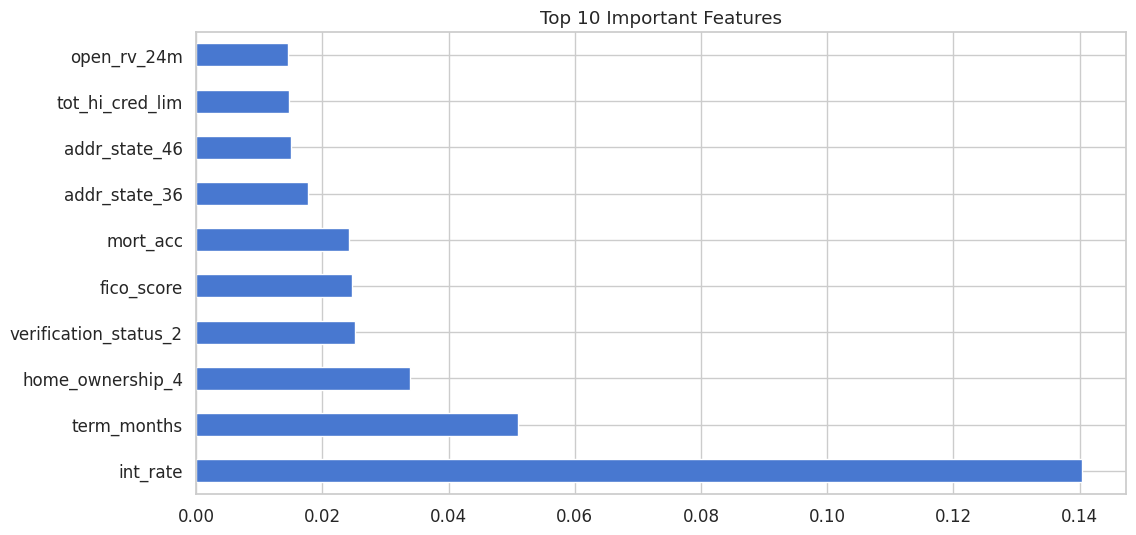

In [140]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(xgb.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False).head(10)

importance.plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

**Lift / Gains Table**

In [141]:
# Lift Table

impact_df["decile"] = pd.qcut(impact_df["PD"], 10, labels=False)

lift_table = impact_df.groupby("decile").agg(
    borrowers=("actual_default","count"),
    defaults=("actual_default","sum")
)

lift_table["default_rate"] = lift_table["defaults"] / lift_table["borrowers"]

print(lift_table.sort_index(ascending=False))

        borrowers  defaults  default_rate
decile                                   
9           10375      5408        0.5213
8           10374      4060        0.3914
7           10374      3180        0.3065
6           10374      2698        0.2601
5           10374      2268        0.2186
4           10374      1883        0.1815
3           10374      1539        0.1484
2           10374      1112        0.1072
1           10374       757        0.0730
0           10375       347        0.0334


**Cumulative Default Capture**

In [142]:
# Cumulative default capture

impact_df = impact_df.sort_values("PD", ascending=False)

impact_df["cum_defaults"] = impact_df["actual_default"].cumsum()
impact_df["cum_default_rate"] = impact_df["cum_defaults"] / impact_df["actual_default"].sum()

capture = impact_df.groupby(pd.qcut(range(len(impact_df)),10)).last()

print(capture[["cum_default_rate"]])

                     cum_default_rate
(-0.001, 10374.1]              0.2326
(10374.1, 20748.2]             0.4072
(20748.2, 31122.3]             0.5440
(31122.3, 41496.4]             0.6600
(41496.4, 51870.5]             0.7575
(51870.5, 62244.6]             0.8385
(62244.6, 72618.7]             0.9047
(72618.7, 82992.8]             0.9525
(82992.8, 93366.9]             0.9851
(93366.9, 103741.0]            1.0000


In [143]:
impact_df.to_csv("credit_risk_dashboard_data.csv", index=False)

In [144]:
impact_df.head()

,actual,probability,credit_score,score_band,PD,Exposure,LGD,Expected_Loss,risk_band,actual_default,decile,cum_defaults,cum_default_rate
1581160,1,0.8481,564,Very Risky,0.8481,20000.0000,0.6000,10177.4182,High Risk,1,9,1,0.0000
620154,1,0.8458,564,Very Risky,0.8458,40000.0000,0.6000,20298.9893,High Risk,1,9,2,0.0001
1520736,1,0.8336,569,Very Risky,0.8336,40000.0000,0.6000,20005.9018,High Risk,1,9,3,0.0001
605474,1,0.8228,573,Very Risky,0.8228,16800.0000,0.6000,8293.7962,High Risk,1,9,4,0.0002
1739183,1,0.8194,574,Very Risky,0.8194,12650.0000,0.6000,6218.9774,High Risk,1,9,5,0.0002


In [145]:
import os

impact_df.to_csv("/kaggle/working/credit_risk_portfolio_results.csv", index=False)

print(os.listdir("/kaggle/working"))

['credit_risk_portfolio_results.csv', 'credit_risk_project', 'credit_risk_dashboard_data.csv', 'credit_risk_project.zip', '.virtual_documents']


In [146]:
strategy_df.to_csv("/kaggle/working/strategy_optimization_results.csv", index=False)

In [147]:
print(os.listdir("/kaggle/working"))

['credit_risk_portfolio_results.csv', 'credit_risk_project', 'credit_risk_dashboard_data.csv', 'strategy_optimization_results.csv', 'credit_risk_project.zip', '.virtual_documents']


In [148]:
import joblib

joblib.dump(xgb, "/kaggle/working/credit_risk_model.pkl")

['/kaggle/working/credit_risk_model.pkl']

In [149]:
joblib.dump(X_train.columns.tolist(), "/kaggle/working/model_features.pkl")

['/kaggle/working/model_features.pkl']

In [150]:
len(X_train.columns)

116

In [151]:
sample_upload = X_test.head(100)

sample_upload.to_csv("/kaggle/working/sample_credit_input.csv", index=False)